In [8]:
import pandas as pd
import re
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Data Loading and Merging

In [9]:
df = pd.read_csv('./data/partidos.csv')
df_ranking = pd.read_csv('./data/ranking_fifa.csv')
df_transfermarkt = pd.read_csv('./data/transfermarkt.csv')

/var/folders/c9/88zz0bpj7wx6d38dghnlklqh0000gn/T/ipykernel_52271/1432938540.py:1: DtypeWarning: Columns (42,43,44,45,46,47,54,55,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166,167,168,169,170,171,172,173,174,175,176,177,178,179,180,181,182,183,184,185,186,187,188,189,190,191,192,193,194,195,196,197,198,199,200,201,202,203,204,205,206,207,208,209,210,211,212,213,214,215,216,217,218,219,220,221,222,223,224,225,226,227,228,229,230,231,232,233,234,235,236,237,238,239,240,241,242,243,244,245,246,247,248,249,250,251,252,253,254,255,256,257,258,259,260,261,262,263,264,265,266,267,268,269,270,271,272,273,274,275,276,277,278,279,280,281,282,283,284,285,286,287,288,289,290,291,292,293,294,295,296,297,298,299,300,3

In [10]:
# Check no duplicates
print(df.shape)
df.drop_duplicates(subset=['URL', 'Fecha', 'Equipo_Local', 'Equipo_Visitante'], keep='last', inplace=True)
print(df.shape)

(3316, 2778)
(3316, 2778)


## Dataset Overview

Summary of the raw dataset after deduplication: shape, variable types, and temporal coverage.

In [11]:
# --- Table 1: Raw dataset summary ---
print(f'Shape: {df.shape[0]} matches x {df.shape[1]} variables')
print(f'Temporal range: {df["Fecha"].min()} - {df["Fecha"].max()}')

tipos = df.dtypes.value_counts()
print('\nTable 1. Variable types in raw dataset')
for t, n in tipos.items():
    print(f'  {str(t):15s}: {n} columns')

print(f'\nTotal missing values: {df.isna().sum().sum():,}')
print(f'Overall missing rate: {df.isna().mean().mean():.1%}')


Shape: 3316 matches x 2778 variables
Temporal range: 01.01.2026 14:00 - 31.12.2025 20:00

Table 1. Variable types in raw dataset
  object         : 2720 columns
  float64        : 57 columns
  int64          : 1 columns

Total missing values: 9,090,640
Overall missing rate: 98.7%


### All Matches

For the new research question (*Which performance statistics predict the match outcome?*), we keep all available matches without filtering by World Cup teams.


In [12]:
# We keep all matches - we do not filter by World Cup teams
print(df.shape)


(3316, 2778)


## Join ranking FIFA

We will create a dictionary to join the FlashScore data with the FIFA ranking.


In [13]:
# KEY = Name in df_ranking (the one we want to change)
# VALUE = Name in df_partidos (the one we want to keep)
mapeo_paises = {
    'EEUU': 'EE. UU.',
    'RI de Irán': 'Irán',
    'República de Corea': 'Corea del Sur',
    'RD del Congo': 'RD Congo',
    'Bosnia y Herzegovina': 'Bosnia-Herzegovina',
    'Baréin': 'Bahréin',
    'RP China': 'China',
    'República Kirguisa': 'Kirguistán',
    'Kazajstán': 'Kazajistán',
    'RDP de Corea': 'Corea del Norte',
    'Guinea-Bissáu': 'Guinea-Bisáu',
    'San Cristóbal y Nieves': 'Saint Kitts y Nevis',
    'Hong Kong, China': 'Hong Kong',
    'Myanmar': 'Birmania',
    'Esuatini': 'Eswatini',
    'Chinese Taipei': 'China Taipei',
    'Bangladesh': 'Bangladés',
    'Samoa Estadounidense': 'Samoa Americana',
    'Brunéi Darussalam': 'Brunéi',
    'República de Irlanda': 'Irlanda',
    'Qatar': 'Catar',
    'Turcas y Caicos': 'Islas Turcas y Caicos',
    'Antigua y Barbuda': 'Antigua & Barbuda',
    'Comoras': 'Comores'
}

# Apply the replacement to the df_ranking column
df_ranking['País'] = df_ranking['País'].replace(mapeo_paises)

# Check if any country is unmatched
paises_df = set(df['Equipo_Local'].unique()).union(set(df['Equipo_Visitante'].unique()))
paises_ranking = set(df_ranking['País'].unique())

huérfanos = paises_df - paises_ranking

if huérfanos:
    print(f"WARNING: {len(huérfanos)} countries have NO associated FIFA ranking:")
    print(sorted(list(huérfanos)))
else:
    print("Success! All countries in your matches have an exact match in the FIFA ranking.")


['Afganistán Sub-20', 'Albania Sub-21', 'Alemania Sub-17', 'Alemania Sub-18', 'Alemania Sub-19', 'Arabia Saudí Sub-20', 'Argelia Sub-20', 'Argelia Sub-23', 'Argentina Sub-17', 'Argentina Sub-20', 'Australia Sub-17', 'Australia Sub-20', 'Austria Sub-17', 'Austria Sub-18', 'Bonaire', 'Bosnia-Herzegovina Sub-19', 'Brasil Sub-20', 'Bulgaria Sub-19', 'Bután Sub-23', 'Bélgica Sub-17', 'Bélgica Sub-21', 'Catar Sub-17', 'Catar Sub-20', 'Catar Sub-23', 'Chile Sub-17', 'Chile Sub-20', 'China Sub-20', 'China Sub-23', 'Chipre Sub-19', 'Colombia Sub-20', 'Corea del Norte Sub-23', 'Corea del Sur Sub-17', 'Corea del Sur Sub-23', 'Costa Rica Sub-20', 'Costa de Marfil Sub-20', 'Costa de Marfil Sub-23', 'Croacia Sub-17', 'Croacia Sub-19', 'EE. UU. Sub-18', 'EE. UU. Sub-19', 'EE. UU. Sub-20', 'EE. UU. Sub-21', 'Ecuador Sub-17', 'Egipto Sub-19', 'Egipto Sub-20', 'Emiratos Árabes Unidos Sub-19', 'Emiratos Árabes Unidos Sub-20', 'Emiratos Árabes Unidos Sub-23', 'Escocia Sub-17', 'Eslovaquia Sub-18', 'Eslova

In [14]:
print(df_ranking.head())


         País  Puntuación       Fecha
0     Francia     1877.32  01-04-2026
1      España     1876.40  01-04-2026
2   Argentina     1874.81  01-04-2026
3  Inglaterra     1825.97  01-04-2026
4    Portugal     1763.83  01-04-2026


We unify the date formats for the JOIN.


In [15]:
# Date handling
# Convert the column to Pandas datetime format, recognising dots and time
df['Fecha'] = pd.to_datetime(df['Fecha'], format='%d.%m.%Y %H:%M')

# (Optional) If the time is not needed, keep only the clean date (YYYY-MM-DD)
df['Fecha'] = df['Fecha'].dt.normalize()
##df['Fecha'] = pd.to_datetime(df['Fecha'], format='%Y-%m-%d')

# Change the date format to YYYY-MM-DD
df_ranking['Fecha'] = pd.to_datetime(df_ranking['Fecha'], format='%d-%m-%Y')
df_ranking['Fecha'] = pd.to_datetime(df_ranking['Fecha']).dt.strftime('%Y-%m-%d')

# Force both columns to pure datetime
df['Fecha'] = pd.to_datetime(df['Fecha']).dt.tz_localize(None)
df_ranking['Fecha'] = pd.to_datetime(df_ranking['Fecha']).dt.tz_localize(None)


In [16]:
# SORT by date (required for merge_asof)
df = df.sort_values('Fecha').reset_index(drop=True)
df_ranking = df_ranking.sort_values('Fecha').reset_index(drop=True)

# ==========================================
# STEP 1: Merge ranking for the HOME TEAM
# ==========================================
df = pd.merge_asof(
    df, 
    df_ranking,
    on='Fecha',               # Same column name in both DataFrames, so we use 'on'
    left_by='Equipo_Local',   
    right_by='País',          
    direction='backward',     
    allow_exact_matches=False 
)

# Rename ONLY the ranking data, leaving 'Fecha' unchanged
df = df.rename(columns={
    'Puntuación': 'Puntos_Local'  # or whatever points variable you have
})

# ==========================================
# STEP 2: Merge ranking for the AWAY TEAM
# ==========================================
df = pd.merge_asof(
    df, 
    df_ranking,
    on='Fecha',               # The 'Fecha' column is still there, ready to use
    left_by='Equipo_Visitante',
    right_by='País',
    direction='backward',
    allow_exact_matches=False 
)

# Rename the away team data
df = df.rename(columns={
    'Puntuación': 'Puntos_Visitante'
})

# Optional: The 'País' column from df_ranking will appear twice, so we clean it up
columnas_a_borrar = [col for col in df.columns if 'País' in col]
print(columnas_a_borrar)
df = df.drop(columns=columnas_a_borrar)

# Check the JOIN
print(df[['Fecha', 'Equipo_Local', 'Puntos_Local', 'Equipo_Visitante', 'Puntos_Visitante']].head())


['País_x', 'País_y']
       Fecha Equipo_Local  Puntos_Local Equipo_Visitante  Puntos_Visitante
0 2019-06-06     Mongolia         915.0           Brunéi             903.0
1 2019-06-06        Macao         925.0        Sri Lanka             886.0
2 2019-06-06         Laos         923.0        Bangladés             907.0
3 2019-06-06      Camboya         970.0         Pakistán             888.0
4 2019-06-06        Bután         917.0             Guam             907.0


## Join Market Value


In [17]:
df_transfermarkt.head()

,Equipo,Valor_Mercado_Millones_Eur
0,Francia,58.58
1,Inglaterra,52.43
2,España,47.03
3,Portugal,38.67
4,Alemania,36.42


In [18]:
diccionario_Transfermarkt = {
    'Estados Unidos': 'EE. UU.',
    'Chequia': 'República Checa',
    'República Democrática del Congo': 'RD Congo',
    'Arabia Saudita': 'Arabia Saudí',
    'Malí': 'Mali',
    'Comoras': 'Comores',
    'Baréin': 'Bahréin',
    'Myanmar': 'Birmania',
    'República del Congo': 'Congo',
    'China Taipéi': 'China Taipei',
    'Esuatini': 'Eswatini',
    
    # Prevention for small island nations (very common when merging these datasets)
    'Antigua y Barbuda': 'Antigua & Barbuda',
    'San Cristóbal y Nieves': 'Saint Kitts y Nevis',
    'Brunéi Darussalam': 'Brunéi',
    'Islas Vírgenes de los Estados Unidos': 'Islas Vírgenes Estadounidenses'
}

# Replace Transfermarkt names with the ones used in your dataset
df_transfermarkt['Equipo'] = df_transfermarkt['Equipo'].replace(diccionario_Transfermarkt)


In [19]:
# ==========================================
# STEP 1: Merge market value for the HOME TEAM
# ==========================================
df = pd.merge(
    df, 
    df_transfermarkt,        
    left_on='Equipo_Local',   
    right_on='Equipo',       
    how='left'               
)

# Rename the home value column and drop the redundant 'Equipo' column
df = df.rename(columns={
    'Valor_Mercado_Millones_Eur': 'Valor_Mercado_Millones_Eur_Local'  
}).drop(columns=['Equipo'])

# ==========================================
# STEP 2: Merge market value for the AWAY TEAM
# ==========================================
df = pd.merge(
    df, 
    df_transfermarkt,        
    left_on='Equipo_Visitante', 
    right_on='Equipo',     
    how='left'
)

# Rename the away value column and drop the redundant 'Equipo' column
df = df.rename(columns={
    'Valor_Mercado_Millones_Eur': 'Valor_Mercado_Millones_Eur_Visitante'
}).drop(columns=['Equipo'])

# Check the JOIN
print(df[['Fecha', 'Equipo_Local', 'Valor_Mercado_Millones_Eur_Local', 'Equipo_Visitante', 'Valor_Mercado_Millones_Eur_Visitante']].head())


       Fecha Equipo_Local  Valor_Mercado_Millones_Eur_Local Equipo_Visitante  \
0 2019-06-06     Mongolia                             0.024           Brunéi   
1 2019-06-06        Macao                             0.016        Sri Lanka   
2 2019-06-06         Laos                             0.057        Bangladés   
3 2019-06-06      Camboya                             0.099         Pakistán   
4 2019-06-06        Bután                             0.037             Guam   

   Valor_Mercado_Millones_Eur_Visitante  
0                                 0.035  
1                                 0.040  
2                                 0.315  
3                                 0.154  
4                                 0.010  


## Continent Data

We group countries by continent so we can use this variable in modelling (facing teams from Africa is not the same as facing teams from Europe).


In [20]:
mapa_continentes = {
    # EUROPE (UEFA)
    'República Checa': 'Europa', 'Bosnia-Herzegovina': 'Europa', 'Suiza': 'Europa',
    'Países Bajos': 'Europa', 'Alemania': 'Europa', 'Escocia': 'Europa',
    'Turquía': 'Europa', 'Suecia': 'Europa', 'España': 'Europa',
    'Bélgica': 'Europa', 'Francia': 'Europa', 'Croacia': 'Europa',
    'Austria': 'Europa', 'Portugal': 'Europa', 'Inglaterra': 'Europa',
    'Noruega': 'Europa',
    
    # SOUTH AMERICA (CONMEBOL)
    'Paraguay': 'Sudamérica', 'Brasil': 'Sudamérica', 'Ecuador': 'Sudamérica',
    'Uruguay': 'Sudamérica', 'Argentina': 'Sudamérica', 'Colombia': 'Sudamérica',
    
    # NORTH AMERICA AND CARIBBEAN (CONCACAF)
    'México': 'Norteamérica', 'Canadá': 'Norteamérica', 'EE. UU.': 'Norteamérica',
    'Haití': 'Norteamérica', 'Curazao': 'Norteamérica', 'Panamá': 'Norteamérica',
    
    # AFRICA (CAF)
    'Sudáfrica': 'Africa', 'Marruecos': 'Africa', 'Egipto': 'Africa',
    'Túnez': 'Africa', 'Costa de Marfil': 'Africa', 'Cabo Verde': 'Africa',
    'Senegal': 'Africa', 'RD Congo': 'Africa', 'Argelia': 'Africa',
    'Ghana': 'Africa',
    
    # ASIA (AFC) - Note: Australia competes in Asia
    'Corea del Sur': 'Asia', 'Catar': 'Asia', 'Japón': 'Asia',
    'Australia': 'Asia', 'Irán': 'Asia', 'Arabia Saudí': 'Asia',
    'Jordania': 'Asia', 'Irak': 'Asia', 'Uzbekistán': 'Asia',
    'Nueva Zelanda': 'Asia'
}


In [21]:
# Apply the dictionary to create the new columns
df['Continente_Local'] = df['Equipo_Local'].map(mapa_continentes)
df['Continente_Visitante'] = df['Equipo_Visitante'].map(mapa_continentes)


In [22]:
print(df['Continente_Local'].value_counts())

Continente_Local
Europa          416
Asia            218
Africa          171
Sudamérica      151
Norteamérica    119
Name: count, dtype: int64


# Data Cleaning

In [23]:
print(df.shape)

# Define the conditions: we want rows that do NOT (~) contain 'sub' (to remove U20, U17, etc.)
# We use na=False to avoid errors when a cell is empty
filtro_local = ~df['Equipo_Local'].astype(str).str.contains('sub', case=False, na=False)
filtro_visitante = ~df['Equipo_Visitante'].astype(str).str.contains('sub', case=False, na=False)

# Filter the dataset by applying both conditions at once (using the & operator)
df = df[filtro_local & filtro_visitante]

# Reset the index to be sequential after dropping rows
df = df.reset_index(drop=True)
print(df.shape)
df.head()


(3316, 2784)
(3144, 2784)


,Unnamed: 0,Fecha,URL,Equipo_Local,Equipo_Visitante,Resultado,Goles_esperados_(xG)_Local,Goles_esperados_(xG)_Visitante,Posesión_Local,Posesión_Visitante,...,82%(347/422)Pases86%(431/501)_Local,82%(347/422)Pases86%(431/501)_Visitante,68%(282/413)Pases58%(180/308)_Local,68%(282/413)Pases58%(180/308)_Visitante,Puntos_Local,Puntos_Visitante,Valor_Mercado_Millones_Eur_Local,Valor_Mercado_Millones_Eur_Visitante,Continente_Local,Continente_Visitante
0,2542,2019-06-06,https://www.flashscore.es/partido/futbol/brune...,Mongolia,Brunéi,2-0Finalizado,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,915.0,903.0,0.024,0.035,NaN,NaN
1,2541,2019-06-06,https://www.flashscore.es/partido/futbol/macao...,Macao,Sri Lanka,1-0Finalizado,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,925.0,886.0,0.016,0.040,NaN,NaN
2,2540,2019-06-06,https://www.flashscore.es/partido/futbol/bangl...,Laos,Bangladés,0-1Finalizado,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,923.0,907.0,0.057,0.315,NaN,NaN
3,2539,2019-06-06,https://www.flashscore.es/partido/futbol/cambo...,Camboya,Pakistán,2-0Finalizado,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,970.0,888.0,0.099,0.154,NaN,NaN
4,2538,2019-06-06,https://www.flashscore.es/partido/futbol/butan...,Bután,Guam,1-0Finalizado,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,917.0,907.0,0.037,0.010,NaN,NaN


The scraper has downloaded many variables, some of which we do not want to use because they are poorly populated or assumed to have low predictive power, so we remove them. We also drop columns that are not relevant and some variables that are highly correlated with others (for example Remates_total and Remates_a_puerta).


In [24]:
# Identify highly correlated variables (above 0.7) to consider dropping them
corr_matrix = df.corr(numeric_only=True).abs()

upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

to_drop = [
    column for column in upper.columns
    if any(upper[column] > 0.7)
]

print("Candidate variables to drop:")
print(to_drop)


Candidate variables to drop:
['Remates_totales_Local', 'Remates_totales_Visitante', 'Remates_a_puerta_Local', 'Remates_a_puerta_Visitante', 'Grandes_ocasiones_Local', 'Grandes_ocasiones_Visitante', 'xG_a_puerta_(xGOT)_Local', 'xG_a_puerta_(xGOT)_Visitante', 'Remates_fuera_Local', 'Remates_fuera_Visitante', 'Remates_rechazados_Local', 'Remates_rechazados_Visitante', 'Remates_dentro_del_área_Local', 'Remates_dentro_del_área_Visitante', 'Remates_fuera_del_área_Local', 'Goles_de_cabeza_Visitante', 'Toques_en_el_área_rival_Local', 'Toques_en_el_área_rival_Visitante', 'Asistencias_esperadas_(xA)_Local', 'Asistencias_esperadas_(xA)_Visitante', 'Faltas_Local', 'Faltas_Visitante', 'Paradas_Local', 'Paradas_Visitante', 'xGOT_enfrentados_Local', 'xGOT_enfrentados_Visitante', 'Tarjetas_rojas_Visitante', 'Penalti_Local', 'Puntos_Local', 'Puntos_Visitante', 'Valor_Mercado_Millones_Eur_Local', 'Valor_Mercado_Millones_Eur_Visitante']


In [25]:
na_pct = df.isna().mean().sort_values(ascending=False) * 100
print(len(na_pct[na_pct > 50]))
print(len(na_pct))

#keep these two metrics for their explanatory power and because they are not highly correlated with other features
cols_protegidas = ['Goles_esperados_(xG)_Local', 'Goles_esperados_(xG)_Visitante']

cols_eliminar = [
    c for c in df.columns 
    if c not in cols_protegidas          # not protected
    and df[c].isna().mean() > 0.5        # and exceeds the threshold
]

df = df.drop(columns=cols_eliminar)
print(df.shape[1])


2744
2784
42


**Figure 1.** Percentage of missing values per variable in the raw dataset (after all joins, before column selection). The dashed line marks the 50% threshold used to drop uninformative variables.

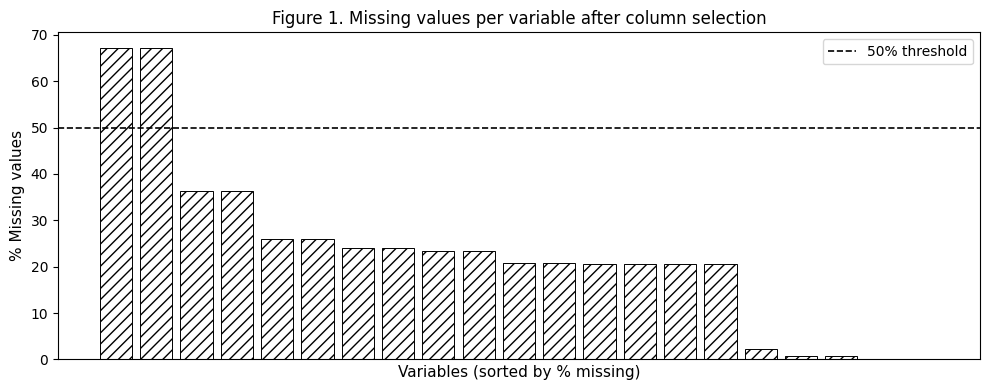

Variables with >50% NaN (protected variables): 2
Variables with any NaN: 21
Complete variables (0% NaN): 4


In [31]:
# --- Figure 1: Missing data before cleaning ---
na_pct_raw = df.isna().mean().sort_values(ascending=False) * 100
na_with_values = na_pct_raw[na_pct_raw > 0]

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(range(len(na_with_values)), na_with_values.values,
              color='white', edgecolor='black', linewidth=0.7)
for bar in bars:
    bar.set_hatch('///')
ax.axhline(50, color='black', linestyle='--', linewidth=1.2, label='50% threshold')
ax.set_xlabel('Variables (sorted by % missing)', fontsize=11)
ax.set_ylabel('% Missing values', fontsize=11)
ax.set_title('Figure 1. Missing values per variable after column selection', fontsize=12)
ax.set_xticks([])
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

print(f'Variables with >50% NaN (protected variables): {(na_pct_raw > 50).sum()}')
print(f'Variables with any NaN: {(na_pct_raw > 0).sum()}')
print(f'Complete variables (0% NaN): {(na_pct_raw == 0).sum()}')

In [27]:
df.corr(numeric_only=True).abs().style.format(precision=2).background_gradient(cmap='coolwarm')
##### not sure if this is correct


,Unnamed: 0,Goles_esperados_(xG)_Local,Goles_esperados_(xG)_Visitante,Remates_totales_Local,Remates_totales_Visitante,Remates_a_puerta_Local,Remates_a_puerta_Visitante,Córneres_Local,Córneres_Visitante,Tarjetas_amarillas_Local,Tarjetas_amarillas_Visitante,Remates_fuera_Local,Remates_fuera_Visitante,Remates_rechazados_Local,Remates_rechazados_Visitante,Fueras_de_juego_Local,Fueras_de_juego_Visitante,Tiros_libres_Local,Tiros_libres_Visitante,Saques_de_banda_Local,Saques_de_banda_Visitante,Faltas_Local,Faltas_Visitante,Paradas_Local,Paradas_Visitante,Puntos_Local,Puntos_Visitante,Valor_Mercado_Millones_Eur_Local,Valor_Mercado_Millones_Eur_Visitante
Unnamed: 0,1.00,0.05,0.03,0.06,0.07,0.01,0.01,0.00,0.01,0.12,0.10,0.02,0.05,0.05,0.02,0.00,0.04,0.05,0.07,0.00,0.00,0.03,0.05,0.03,0.02,0.13,0.13,0.17,0.16
Goles_esperados_(xG)_Local,0.05,1.00,0.38,0.78,0.45,0.78,0.36,0.46,0.36,0.24,0.09,0.55,0.39,0.48,0.30,0.12,0.15,0.09,0.14,0.04,0.28,0.14,0.04,0.31,0.55,0.43,0.37,0.37,0.24
Goles_esperados_(xG)_Visitante,0.03,0.38,1.00,0.45,0.76,0.40,0.77,0.36,0.45,0.19,0.10,0.36,0.54,0.30,0.45,0.07,0.12,0.02,0.01,0.20,0.08,0.00,0.04,0.56,0.33,0.38,0.39,0.22,0.34
Remates_totales_Local,0.06,0.78,0.45,1.00,0.42,0.77,0.38,0.61,0.44,0.22,0.16,0.81,0.36,0.73,0.32,0.13,0.17,0.15,0.10,0.12,0.28,0.15,0.07,0.31,0.71,0.44,0.31,0.33,0.22
Remates_totales_Visitante,0.07,0.45,0.76,0.42,1.00,0.39,0.78,0.42,0.63,0.25,0.10,0.36,0.79,0.32,0.73,0.12,0.14,0.03,0.03,0.22,0.17,0.02,0.05,0.72,0.31,0.33,0.40,0.21,0.31
Remates_a_puerta_Local,0.01,0.78,0.40,0.77,0.39,1.00,0.33,0.46,0.37,0.21,0.10,0.43,0.33,0.35,0.26,0.13,0.15,0.13,0.05,0.02,0.24,0.09,0.09,0.25,0.87,0.38,0.34,0.30,0.21
Remates_a_puerta_Visitante,0.01,0.36,0.77,0.38,0.78,0.33,1.00,0.34,0.47,0.20,0.12,0.32,0.40,0.27,0.37,0.10,0.16,0.01,0.02,0.20,0.09,0.00,0.05,0.88,0.25,0.34,0.33,0.21,0.27
Córneres_Local,0.00,0.46,0.36,0.61,0.42,0.46,0.34,1.00,0.39,0.19,0.11,0.50,0.35,0.51,0.29,0.10,0.17,0.10,0.07,0.15,0.23,0.12,0.07,0.31,0.46,0.31,0.31,0.20,0.19
Córneres_Visitante,0.01,0.36,0.45,0.44,0.63,0.37,0.47,0.39,1.00,0.17,0.12,0.38,0.50,0.32,0.52,0.11,0.12,0.01,0.02,0.21,0.20,0.02,0.04,0.45,0.31,0.31,0.31,0.21,0.22
Tarjetas_amarillas_Local,0.12,0.24,0.19,0.22,0.25,0.21,0.20,0.19,0.17,1.00,0.14,0.16,0.18,0.17,0.19,0.04,0.03,0.09,0.29,0.00,0.08,0.32,0.07,0.17,0.16,0.13,0.19,0.11,0.15


In [28]:
# Define the strict list of variables for the model
# We removed those with more than 50% missing values
# We also identified those highly correlated with other variables
# We handle this by defining the following list, which omits several features
columnas = [
    'Fecha', 'Equipo_Local', 'Equipo_Visitante', 'Resultado', 
    'Goles_esperados_(xG)_Local', 'Goles_esperados_(xG)_Visitante', 
    'Posesión_Local', 'Posesión_Visitante', 
    # 'Remates_totales_Local', 'Remates_totales_Visitante', 
    'Remates_a_puerta_Local', 'Remates_a_puerta_Visitante', 
    # 'Grandes_ocasiones_Local', 'Grandes_ocasiones_Visitante', 
    'Córneres_Local', 'Córneres_Visitante', 
    'Pases_Local', 'Pases_Visitante', 
    'Tarjetas_amarillas_Local', 'Tarjetas_amarillas_Visitante',
    # 'Toques_en_el_área_rival_Local', 'Toques_en_el_área_rival_Visitante', 
    # 'Fueras_de_juego_Local', 'Fueras_de_juego_Visitante', 
    # 'Tiros_libres_Local', 'Tiros_libres_Visitante', 
    # 'Pases_en_el_tercio_final_Local', 'Pases_en_el_tercio_final_Visitante', 
    # 'Saques_de_banda_Local', 'Saques_de_banda_Visitante', 
    'Faltas_Local', 'Faltas_Visitante', 
    # 'Entradas_Local', 'Entradas_Visitante', 
    # 'Duelos_ganados_Local', 'Duelos_ganados_Visitante', 
    'Paradas_Local', 'Paradas_Visitante',
    'Puntos_Local', 'Puntos_Visitante',
    #'Peso_Local', 'Peso_Visitante',
    'Valor_Mercado_Millones_Eur_Local', 'Valor_Mercado_Millones_Eur_Visitante'
]

# Filter using list comprehension
columnas_existentes = [col for col in columnas if col in df.columns]

# Overwrite the DataFrame with the validated subset
df = df[columnas_existentes]


In [29]:
# Check the resulting dataset
pd.set_option('display.max_columns', None)
print(df.shape)
df.head()
df.describe()


(3144, 24)


,Fecha,Goles_esperados_(xG)_Local,Goles_esperados_(xG)_Visitante,Remates_a_puerta_Local,Remates_a_puerta_Visitante,Córneres_Local,Córneres_Visitante,Tarjetas_amarillas_Local,Tarjetas_amarillas_Visitante,Faltas_Local,Faltas_Visitante,Paradas_Local,Paradas_Visitante,Puntos_Local,Puntos_Visitante,Valor_Mercado_Millones_Eur_Local,Valor_Mercado_Millones_Eur_Visitante
count,3144,1032.000000,1032.000000,2495.000000,2495.000000,2495.000000,2495.000000,2390.000000,2390.000000,2328.000000,2328.000000,2411.000000,2411.000000,3122.000000,3121.000000,3141.000000,3140.000000
mean,2023-09-28 15:34:21.068702208,1.464564,1.125388,4.490982,3.647695,4.989980,4.030461,1.841841,2.054393,12.225086,12.278780,2.479469,2.973455,1330.970368,1321.980381,6.665954,6.212583
min,2019-06-06 00:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,726.030000,727.950000,0.000000,0.000000
25%,2022-01-30 00:00:00,0.670000,0.450000,2.000000,2.000000,3.000000,2.000000,1.000000,1.000000,9.000000,9.000000,1.000000,1.000000,1140.142500,1135.420000,0.297000,0.285000
50%,2024-03-21 00:00:00,1.250000,0.930000,4.000000,3.000000,4.000000,4.000000,2.000000,2.000000,12.000000,12.000000,2.000000,3.000000,1343.385000,1334.370000,1.380000,1.330000
75%,2025-03-20 00:00:00,2.030000,1.530000,6.000000,5.000000,7.000000,6.000000,3.000000,3.000000,15.000000,15.000000,4.000000,4.000000,1511.135000,1500.520000,7.640000,7.405000
max,2026-06-28 00:00:00,9.570000,6.340000,22.000000,25.000000,20.000000,20.000000,7.000000,11.000000,33.000000,37.000000,14.000000,15.000000,1901.480000,1901.480000,58.580000,58.580000
std,NaN,1.072548,0.898599,3.105957,2.713189,3.278001,2.895098,1.338207,1.392879,4.408456,4.513365,2.028401,2.245909,253.908292,248.866940,11.295491,10.847050


Data such as xG is not available for very old dates, so we keep only matches with more recent dates.


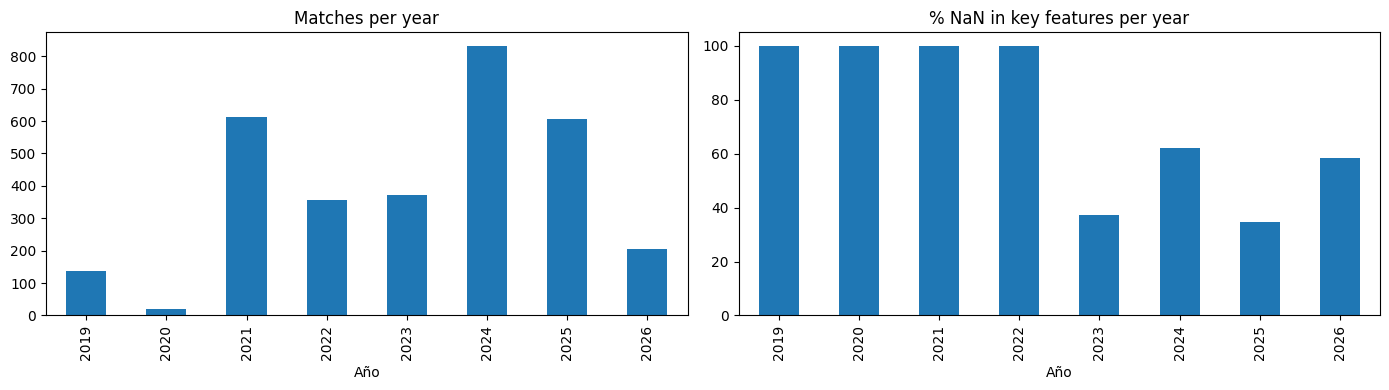

In [30]:
import matplotlib.pyplot as plt

# Matches per year
df['Año'] = df['Fecha'].dt.year
conteo = df.groupby('Año').size()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Match volume per year
conteo.plot(kind='bar', ax=axes[0], title='Matches per year')

# % of NaN in key features per year (the actual justification)
features_clave = ['Goles_esperados_(xG)_Local', 'Goles_esperados_(xG)_Visitante']  # add xG or other features if available
pct_nans = df.groupby('Año')[features_clave].apply(lambda x: x.isna().mean().mean() * 100)
pct_nans.plot(kind='bar', ax=axes[1], title='% NaN in key features per year')

plt.tight_layout()
plt.show()


In [26]:
# Remove very old dates (little information available)
fecha_corte = pd.to_datetime('2023-01-01')
df = df[df['Fecha'] >= fecha_corte].copy()
print(df.shape)
df.head()


(2017, 25)


,Fecha,Equipo_Local,Equipo_Visitante,Resultado,Goles_esperados_(xG)_Local,Goles_esperados_(xG)_Visitante,Posesión_Local,Posesión_Visitante,Remates_a_puerta_Local,Remates_a_puerta_Visitante,Córneres_Local,Córneres_Visitante,Pases_Local,Pases_Visitante,Tarjetas_amarillas_Local,Tarjetas_amarillas_Visitante,Faltas_Local,Faltas_Visitante,Paradas_Local,Paradas_Visitante,Puntos_Local,Puntos_Visitante,Valor_Mercado_Millones_Eur_Local,Valor_Mercado_Millones_Eur_Visitante,Año
1127,2023-03-23,Portugal,Liechtenstein,4-0Finalizado,4.16,0.03,71%,29%,11.0,1.0,12.0,0.0,91%(677/740),56%(91/162),NaN,NaN,5.0,6.0,1.0,7.0,1702.54,859.84,38.670,0.026,2023
1128,2023-03-23,San Marino,Irlanda del Norte,0-2Finalizado,0.03,1.79,30%,70%,1.0,4.0,0.0,9.0,71%(205/287),87%(582/668),0.0,1.0,16.0,9.0,2.0,1.0,763.15,1396.55,0.044,3.470,2023
1129,2023-03-23,Kazajistán,Eslovenia,1-2Finalizado,0.63,1.49,43%,57%,2.0,6.0,3.0,4.0,75%(225/301),86%(408/474),2.0,1.0,17.0,11.0,4.0,1.0,1163.09,1389.06,0.652,4.020,2023
1130,2023-03-23,Eslovaquia,Luxemburgo,0-0Finalizado,1.25,0.61,48%,52%,3.0,2.0,9.0,2.0,80%(321/401),78%(334/428),0.0,2.0,11.0,17.0,2.0,3.0,1425.58,1245.35,2.300,0.639,2023
1131,2023-03-23,Italia,Inglaterra,1-2Finalizado,1.16,2.07,49%,51%,1.0,4.0,7.0,3.0,81%(420/516),82%(318/389),3.0,5.0,13.0,6.0,2.0,0.0,1723.56,1774.19,13.730,52.430,2023


## Feature Engineering

Some variables come in unusual formats after scraping. For example, ``Pases_Local`` comes as `91%(814/897)`. We will extract the individual values to create usable variables for modelling.


### Cleaning the Result Variable


In [27]:
def limpiar_resultados_flashscore(texto):
    texto = str(texto).strip()
    
    # 1. Case: match decided in 90 minutes (e.g. "2-1Finalizado")
    match_fin = re.match(r'^(\d+-\d+)\s*Finalizado', texto)
    if match_fin:
        resultado_90 = match_fin.group(1)
        return pd.Series([resultado_90, None, None])
        
    # 2. Case: match decided in extra time (e.g. "1-0(0-0)Tras la prórroga")
    # We capture 1-0 as the final score and 0-0 as the regular-time score
    match_pro = re.match(r'^(\d+-\d+)\s*\(\s*(\d+-\d+)\s*\)\s*Tras la prórroga', texto)
    if match_pro:
        resultado_120 = match_pro.group(1) # Final score after 120 min (1-0)
        resultado_90 = match_pro.group(2)  # Score at 90 min (0-0)
        
        # FIX: We assign the draw (0-0) as the main 90-min result
        # and store 1-0 in the extra time column
        return pd.Series([resultado_90, resultado_120, None])
        
    # 3. Case: match decided on penalties (e.g. "2-1(1-1)Tras los penaltis")
    match_pen = re.match(r'^(\d+-\d+)\s*\(\s*(\d+-\d+)\s*\)\s*Tras los penaltis', texto)
    if match_pen:
        resultado_penaltis = match_pen.group(1) # Penalty shootout result (2-1)
        resultado_120 = match_pen.group(2)      # Match score after 120 min (1-1)
        
        # We assign the draw (1-1) as the main result since both stages ended in a draw
        return pd.Series([resultado_120, resultado_120, resultado_penaltis])
    # Case 4: match lost by walkover (e.g. "0-3Por perdido")
    match_walkover = re.match(r'^(\d+-\d+)\s*Por perdido', texto)
    if match_walkover:
        return pd.Series([match_walkover.group(1), None, None])    
    # 5. Residual case (postponed, suspended, or other formats)
    return pd.Series([texto, None, None])

# Apply the function
nuevas_columnas = ['Resultado', 'Resultado_Prorroga', 'Resultado_Penaltis']
df[nuevas_columnas] = df['Resultado'].apply(limpiar_resultados_flashscore)
print(len(df))
print(df['Resultado'].isna().sum())
print(df[['Resultado', 'Resultado_Prorroga', 'Resultado_Penaltis']].head())
print(df['Resultado_Penaltis'].notna().sum(), "matches decided on penalties")
print(df['Resultado_Prorroga'].notna().sum(), "matches with extra time")
print(df['Resultado'].isna().sum(), "results not parsed (residual case)")


2017
0
     Resultado Resultado_Prorroga Resultado_Penaltis
1127       4-0                NaN                NaN
1128       0-2                NaN                NaN
1129       1-2                NaN                NaN
1130       0-0                NaN                NaN
1131       1-2                NaN                NaN
30 partidos a penaltis
42 partidos con prórroga
0 resultados sin parsear (caso residual)


### Cleaning Variables with (%)


In [28]:
# Specify the columns that have this complex format
columnas_combinadas = ['Pases_Local', 'Pases_Visitante'] 

for col in columnas_combinadas:
    extraccion = df[col].astype(str).str.extract(r'(\d+)%\((\d+)/\d+\)')
    
    # Create two new columns from the extraction and convert them to numeric.
    df[f"{col}_Pct"] = pd.to_numeric(extraccion[0], errors='coerce')
    df[f"{col}_Exitosos"] = pd.to_numeric(extraccion[1], errors='coerce')

# Optional: check the result and drop the original messy column
print(df[[f"{columnas_combinadas[0]}_Pct", f"{columnas_combinadas[0]}_Exitosos"]].head())

df = df.drop(columns=columnas_combinadas) # Uncomment to drop the original columns


      Pases_Local_Pct  Pases_Local_Exitosos
1127             91.0                 677.0
1128             71.0                 205.0
1129             75.0                 225.0
1130             80.0                 321.0
1131             81.0                 420.0


In [29]:
# List of column names that contain percentages
columnas_porcentaje = ['Posesión_Local', 'Posesión_Visitante', 'Pases_Local_Pct', 'Pases_Visitante_Pct'] 

for col in columnas_porcentaje:
    df[col] = df[col].astype(str).str.replace('%', '').astype(float) 

# Check the result
print(df[['Posesión_Local', 'Posesión_Visitante']].head())


      Posesión_Local  Posesión_Visitante
1127            71.0                29.0
1128            30.0                70.0
1129            43.0                57.0
1130            48.0                52.0
1131            49.0                51.0


## Temporal Filter

We remove the 2026 World Cup matches (which are test data, not training data) and keep only the prior historical data for analysis.


In [30]:
print(f"Total original rows: {len(df)}")

# Keep only matches before the 2026 World Cup
fecha_corte = pd.to_datetime('2026-06-11')
df = df[df['Fecha'] < fecha_corte].copy()

print(f"Rows for analysis: {len(df)}")


Filas totales originales: 2017
Filas para análisis: 1945


## Checking Missing Values


In [31]:
# Variables with missing values
df.isnull().sum()


Fecha                                      0
Equipo_Local                               0
Equipo_Visitante                           0
Resultado                                  0
Goles_esperados_(xG)_Local               913
Goles_esperados_(xG)_Visitante           913
Posesión_Local                           317
Posesión_Visitante                       317
Remates_a_puerta_Local                   316
Remates_a_puerta_Visitante               316
Córneres_Local                           316
Córneres_Visitante                       316
Tarjetas_amarillas_Local                 386
Tarjetas_amarillas_Visitante             386
Faltas_Local                             369
Faltas_Visitante                         369
Paradas_Local                            400
Paradas_Visitante                        400
Puntos_Local                              21
Puntos_Visitante                          22
Valor_Mercado_Millones_Eur_Local           3
Valor_Mercado_Millones_Eur_Visitante       4
Año       

We use the Possession variable to remove rows with NAs. This is because possession is the most basic match statistic. If this data is missing, we assume there is not enough useful information to model the match and we therefore drop those observations.


In [32]:
# 1. Columns that MUST be complete
columnas_obligatorias = ['Posesión_Visitante', 'Posesión_Local'] 

# 2. Drop rows that have at least one NA in the required columns
df = df.dropna(subset=columnas_obligatorias)

# Reset the index after dropping rows
df = df.reset_index(drop=True)

# Remaining dataset after dropping rows with NAs in critical columns
print(df.shape)

# Check
df.isnull().sum()


(1628, 29)


Fecha                                      0
Equipo_Local                               0
Equipo_Visitante                           0
Resultado                                  0
Goles_esperados_(xG)_Local               596
Goles_esperados_(xG)_Visitante           596
Posesión_Local                             0
Posesión_Visitante                         0
Remates_a_puerta_Local                     0
Remates_a_puerta_Visitante                 0
Córneres_Local                             0
Córneres_Visitante                         0
Tarjetas_amarillas_Local                  71
Tarjetas_amarillas_Visitante              71
Faltas_Local                              53
Faltas_Visitante                          53
Paradas_Local                             84
Paradas_Visitante                         84
Puntos_Local                               7
Puntos_Visitante                           8
Valor_Mercado_Millones_Eur_Local           0
Valor_Mercado_Millones_Eur_Visitante       0
Año       

# Data Imputation

To avoid losing too many observations, we impute missing values using `IterativeImputer` from ``sklearn``. This is an advanced option, but since the goal of this notebook is to learn and share, we use this method.

The parameters are not fully optimised; the goal here is simply to obtain a complete and reasonable dataset, not a perfect one.


In [33]:
from sklearn.experimental import enable_iterative_imputer 
from sklearn.impute import IterativeImputer
from sklearn.ensemble import RandomForestRegressor

# 1. Split the dataset: untouchable columns (text/identifiers) and columns to impute
columnas_texto = ['Fecha', 'Equipo_Local', 'Equipo_Visitante', 'Resultado', 'Resultado_Prorroga', 'Resultado_Penaltis'] 
columnas_numericas = [col for col in df.columns if col not in columnas_texto]

# 2. Set up the Imputer
# We use RandomForest internally because it captures non-linear relationships in football very well
imputador = IterativeImputer(
    estimator=RandomForestRegressor(n_estimators=50, random_state=42),
    max_iter=10,
    random_state=42,
    min_value=0  # No one can have -2 shots or -0.5 xG
)

# 3. Fit and apply the imputation only on numerical variables
df_imputado = pd.DataFrame(
    imputador.fit_transform(df[columnas_numericas]), 
    columns=columnas_numericas, 
    index=df.index
)

# 4. Rejoin the untouched text columns with the cleaned numerical ones
df = pd.concat([df[columnas_texto], df_imputado], axis=1)

# Check that all NAs have been eliminated
print(df.isna().sum())


Fecha                                      0
Equipo_Local                               0
Equipo_Visitante                           0
Resultado                                  0
Resultado_Prorroga                      1589
Resultado_Penaltis                      1600
Goles_esperados_(xG)_Local                 0
Goles_esperados_(xG)_Visitante             0
Posesión_Local                             0
Posesión_Visitante                         0
Remates_a_puerta_Local                     0
Remates_a_puerta_Visitante                 0
Córneres_Local                             0
Córneres_Visitante                         0
Tarjetas_amarillas_Local                   0
Tarjetas_amarillas_Visitante               0
Faltas_Local                               0
Faltas_Visitante                           0
Paradas_Local                              0
Paradas_Visitante                          0
Puntos_Local                               0
Puntos_Visitante                           0
Valor_Merc

c:\Users\javie\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\impute\_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


We build variables.


In [ ]:
df[["Goles_Local", "Goles_Visitante"]] = df["Resultado"].str.split("-", expand=True)
df["Goles_Local"] = pd.to_numeric(df["Goles_Local"], errors="coerce")
df["Goles_Visitante"] = pd.to_numeric(df["Goles_Visitante"], errors="coerce")

# Multi-class target: 1=Home wins, X=Draw, 2=Away wins
df["Resultado_1X2"] = df.apply(lambda row: "1" if row["Goles_Local"] > row["Goles_Visitante"] 
                                         else ("X" if row["Goles_Local"] == row["Goles_Visitante"] else "2"), axis=1)

# Continuous target: goal difference (for regression)
df["Goles_diff"] = df["Goles_Local"] - df["Goles_Visitante"]

# Binary target: home win (1) or not (0)
df["Victoria_Local"] = (df["Goles_Local"] > df["Goles_Visitante"]).astype(int)

print(df['Resultado_1X2'].value_counts())
print(f"Home win rate: {df['Victoria_Local'].mean():.2%}")
df.head()


Resultado_1X2
1    705
2    526
X    397
Name: count, dtype: int64
Victoria local rate: 43.30%


,Fecha,Equipo_Local,Equipo_Visitante,Resultado,Resultado_Prorroga,Resultado_Penaltis,Goles_esperados_(xG)_Local,Goles_esperados_(xG)_Visitante,Posesión_Local,Posesión_Visitante,Remates_a_puerta_Local,Remates_a_puerta_Visitante,Córneres_Local,Córneres_Visitante,Tarjetas_amarillas_Local,Tarjetas_amarillas_Visitante,Faltas_Local,Faltas_Visitante,Paradas_Local,Paradas_Visitante,Puntos_Local,Puntos_Visitante,Valor_Mercado_Millones_Eur_Local,Valor_Mercado_Millones_Eur_Visitante,Año,Pases_Local_Pct,Pases_Local_Exitosos,Pases_Visitante_Pct,Pases_Visitante_Exitosos,Goles_Local,Goles_Visitante,Resultado_1X2,Goles_diff,Victoria_Local
0,2023-03-23,Portugal,Liechtenstein,4-0,NaN,NaN,4.16,0.03,71.0,29.0,11.0,1.0,12.0,0.0,0.4,1.46,5.0,6.0,1.0,7.0,1702.54,859.84,38.670,0.026,2023.0,91.0,677.0,56.0,91.0,4,0,1,4,1
1,2023-03-23,San Marino,Irlanda del Norte,0-2,NaN,NaN,0.03,1.79,30.0,70.0,1.0,4.0,0.0,9.0,0.0,1.00,16.0,9.0,2.0,1.0,763.15,1396.55,0.044,3.470,2023.0,71.0,205.0,87.0,582.0,0,2,2,-2,0
2,2023-03-23,Kazajistán,Eslovenia,1-2,NaN,NaN,0.63,1.49,43.0,57.0,2.0,6.0,3.0,4.0,2.0,1.00,17.0,11.0,4.0,1.0,1163.09,1389.06,0.652,4.020,2023.0,75.0,225.0,86.0,408.0,1,2,2,-1,0
3,2023-03-23,Eslovaquia,Luxemburgo,0-0,NaN,NaN,1.25,0.61,48.0,52.0,3.0,2.0,9.0,2.0,0.0,2.00,11.0,17.0,2.0,3.0,1425.58,1245.35,2.300,0.639,2023.0,80.0,321.0,78.0,334.0,0,0,X,0,0
4,2023-03-23,Italia,Inglaterra,1-2,NaN,NaN,1.16,2.07,49.0,51.0,1.0,4.0,7.0,3.0,3.0,5.00,13.0,6.0,2.0,0.0,1723.56,1774.19,13.730,52.430,2023.0,81.0,420.0,82.0,318.0,1,2,2,-1,0


We will build "Share" variables. Essentially, out of the total shots, what percentage belongs to the home team and what percentage to the away team. These variables tend to work very well in sports, as they indicate the offensive power of a team not in absolute terms but relative to the match.


In [40]:
# Structure: (Home Column Name, Away Column Name, Name for the new metric)
pares_metricas = [
    ('Goles_esperados_(xG)_Local', 'Goles_esperados_(xG)_Visitante', 'xG'),
    # ('Remates_totales_Local', 'Remates_totales_Visitante', 'Remates_Totales'),
    ('Remates_a_puerta_Local', 'Remates_a_puerta_Visitante', 'Remates_Puerta'),
    # ('Grandes_ocasiones_Local', 'Grandes_ocasiones_Visitante', 'Grandes_Ocasiones'),
    ('Córneres_Local', 'Córneres_Visitante', 'Corneres'),
    # ('Toques_en_el_área_rival_Local', 'Toques_en_el_área_rival_Visitante', 'Toques_Area_Rival'),
    # ('Duelos_ganados_Local', 'Duelos_ganados_Visitante', 'Duelos_Ganados'),
    ('Paradas_Local', 'Paradas_Visitante', 'Paradas'), # Note: A high share here means you were dominated
    ('Pases_Local_Exitosos', 'Pases_Visitante_Exitosos', 'Pases_Exitosos'),
    # ('Pases_en_el_tercio_final_Local_Exitosos', 'Pases_en_el_tercio_final_Visitante_Exitosos', 'Pases_Tercio_Final'),
    # ('Entradas_Local_Exitosos', 'Entradas_Visitante_Exitosos', 'Entradas_Exitosas'),
    ('Goles_Local', 'Goles_Visitante', 'Goles'),
    ('Puntos_Local', 'Puntos_Visitante', 'Puntos'),
    ('Valor_Mercado_Millones_Eur_Local', 'Valor_Mercado_Millones_Eur_Visitante', 'Valor_Mercado_Millones_Eur')
]

for col_local, col_visitante, nombre_base in pares_metricas:
    # 1. Calculate the total volume of the metric in the match
    suma_total = df[col_local] + df[col_visitante]
    
    # 2. Calculate the Home Share
    # np.where(condition, value_if_true, value_if_false)
    df[f'{nombre_base}_Share_Local'] = np.where(
        suma_total > 0,
        df[col_local] / suma_total,
        0.5  # Assign 0.5 when total is 0 (e.g. 0 goals from both = balanced match)
    )
    
    # 3. The Away Share is mathematically the inverse (1 - Home)
    df[f'{nombre_base}_Share_Visitante'] = 1 - df[f'{nombre_base}_Share_Local']

# Show a sample of the newly generated columns
columnas_generadas = [f"{t[2]}_Share_Local" for t in pares_metricas]

# Check 
df[['Equipo_Local', 'Equipo_Visitante', 'Resultado'] + columnas_generadas].head()


,Equipo_Local,Equipo_Visitante,Resultado,xG_Share_Local,Remates_Puerta_Share_Local,Corneres_Share_Local,Paradas_Share_Local,Pases_Exitosos_Share_Local,Goles_Share_Local,Puntos_Share_Local,Valor_Mercado_Millones_Eur_Share_Local
0,Portugal,Liechtenstein,4-0,0.992840,0.916667,1.000000,0.125000,0.881510,1.000000,0.664437,0.999328
1,San Marino,Irlanda del Norte,0-2,0.016484,0.200000,0.000000,0.666667,0.260483,0.000000,0.353359,0.012521
2,Kazajistán,Eslovenia,1-2,0.297170,0.250000,0.428571,0.800000,0.355450,0.333333,0.455729,0.139555
3,Eslovaquia,Luxemburgo,0-0,0.672043,0.600000,0.818182,0.400000,0.490076,0.500000,0.533739,0.782579
4,Italia,Inglaterra,1-2,0.359133,0.200000,0.700000,1.000000,0.569106,0.333333,0.492762,0.207527


## Raw Statistics Differences (Home - Away)

For the new research question, the match statistics themselves are our **main variables of interest**. We create Home − Away differences for each metric: a positive value indicates a home team advantage.

Unlike the original objective (predicting future matches), here there is NO data leakage because we specifically want to analyse how match statistics relate to the outcome.


In [41]:
metricas_diff = [
    ('Goles_esperados_(xG)_Local', 'Goles_esperados_(xG)_Visitante', 'xG_diff'),
    ('Posesión_Local', 'Posesión_Visitante', 'Posesion_diff'),
    ('Remates_a_puerta_Local', 'Remates_a_puerta_Visitante', 'Remates_puerta_diff'),
    ('Córneres_Local', 'Córneres_Visitante', 'Corneres_diff'),
    ('Pases_Local_Exitosos', 'Pases_Visitante_Exitosos', 'Pases_Exitosos_diff'),
    ('Pases_Local_Pct', 'Pases_Visitante_Pct', 'Pases_Pct_diff'),
    ('Tarjetas_amarillas_Local', 'Tarjetas_amarillas_Visitante', 'Tarjetas_diff'),
    ('Faltas_Local', 'Faltas_Visitante', 'Faltas_diff'),
    ('Paradas_Local', 'Paradas_Visitante', 'Paradas_diff'),
    ('Puntos_Local', 'Puntos_Visitante', 'FIFA_diff'),
    ('Valor_Mercado_Millones_Eur_Local', 'Valor_Mercado_Millones_Eur_Visitante', 'Valor_Mercado_diff'),
]

for col_local, col_visitante, nombre in metricas_diff:
    if col_local in df.columns and col_visitante in df.columns:
        df[nombre] = df[col_local] - df[col_visitante]
    else:
        print(f'WARNING: column not found for {nombre}')

cols_diff = [n for _, _, n in metricas_diff if n in df.columns]
print('Difference columns created:', cols_diff)
df[cols_diff].head()


Columnas de diferencia creadas: ['xG_diff', 'Posesion_diff', 'Remates_puerta_diff', 'Corneres_diff', 'Pases_Exitosos_diff', 'Pases_Pct_diff', 'Tarjetas_diff', 'Faltas_diff', 'Paradas_diff', 'FIFA_diff', 'Valor_Mercado_diff']


,xG_diff,Posesion_diff,Remates_puerta_diff,Corneres_diff,Pases_Exitosos_diff,Pases_Pct_diff,Tarjetas_diff,Faltas_diff,Paradas_diff,FIFA_diff,Valor_Mercado_diff
0,4.13,42.0,10.0,12.0,586.0,35.0,-1.06,-1.0,-6.0,842.70,38.644
1,-1.76,-40.0,-3.0,-9.0,-377.0,-16.0,-1.00,7.0,1.0,-633.40,-3.426
2,-0.86,-14.0,-4.0,-1.0,-183.0,-11.0,1.00,6.0,3.0,-225.97,-3.368
3,0.64,-4.0,1.0,7.0,-13.0,2.0,-2.00,-6.0,-1.0,180.23,1.661
4,-0.91,-2.0,-3.0,4.0,102.0,-1.0,-2.00,7.0,2.0,-50.63,-38.700


## Control Variables: Team Quality

We add variables derived from the FIFA ranking and market value as **team quality controls**. They allow us to isolate the effect of match performance statistics from the intrinsic level of the teams.


In [42]:
print(df.shape)
df.tail()


(1628, 61)


,Fecha,Equipo_Local,Equipo_Visitante,Resultado,Resultado_Prorroga,Resultado_Penaltis,Goles_esperados_(xG)_Local,Goles_esperados_(xG)_Visitante,Posesión_Local,Posesión_Visitante,Remates_a_puerta_Local,Remates_a_puerta_Visitante,Córneres_Local,Córneres_Visitante,Tarjetas_amarillas_Local,Tarjetas_amarillas_Visitante,Faltas_Local,Faltas_Visitante,Paradas_Local,Paradas_Visitante,Puntos_Local,Puntos_Visitante,Valor_Mercado_Millones_Eur_Local,Valor_Mercado_Millones_Eur_Visitante,Año,Pases_Local_Pct,Pases_Local_Exitosos,Pases_Visitante_Pct,Pases_Visitante_Exitosos,Goles_Local,Goles_Visitante,Resultado_1X2,Goles_diff,Victoria_Local,xG_Share_Local,xG_Share_Visitante,Remates_Puerta_Share_Local,Remates_Puerta_Share_Visitante,Corneres_Share_Local,Corneres_Share_Visitante,Paradas_Share_Local,Paradas_Share_Visitante,Pases_Exitosos_Share_Local,Pases_Exitosos_Share_Visitante,Goles_Share_Local,Goles_Share_Visitante,Puntos_Share_Local,Puntos_Share_Visitante,Valor_Mercado_Millones_Eur_Share_Local,Valor_Mercado_Millones_Eur_Share_Visitante,xG_diff,Posesion_diff,Remates_puerta_diff,Corneres_diff,Pases_Exitosos_diff,Pases_Pct_diff,Tarjetas_diff,Faltas_diff,Paradas_diff,FIFA_diff,Valor_Mercado_diff
1623,2026-05-28,Egipto,Rusia,1-0,NaN,NaN,1.1200,0.5200,54.0,46.0,4.0,1.0,5.0,6.0,1.00,2.0,13.00,19.00,1.00,3.00,1563.24,1525.60,4.480,7.350,2026.0,86.00,402.00,85.00,334.00,1,0,1,1,1,0.682927,0.317073,0.800000,0.200000,0.454545,0.545455,0.250000,0.750000,0.546196,0.453804,1.0,0.0,0.506093,0.493907,0.378698,0.621302,0.6000,8.0,3.0,-1.0,68.00,1.0,-1.00,-6.00,-2.00,37.64,-2.870
1624,2026-05-28,Irlanda,Catar,1-0,NaN,NaN,1.9000,0.4000,52.0,48.0,3.0,1.0,7.0,3.0,1.18,2.7,9.00,16.00,1.00,2.00,1436.63,1454.96,5.440,0.766,2026.0,87.00,392.00,88.00,358.00,1,0,1,1,1,0.826087,0.173913,0.750000,0.250000,0.700000,0.300000,0.333333,0.666667,0.522667,0.477333,1.0,0.0,0.496830,0.503170,0.876571,0.123429,1.5000,4.0,2.0,4.0,34.00,-1.0,-1.52,-7.00,-1.00,-18.33,4.674
1625,2026-05-29,Sudáfrica,Nicaragua,0-0,NaN,NaN,2.1800,0.0700,85.0,15.0,6.0,0.0,6.0,1.0,0.00,2.0,8.00,10.00,0.00,7.00,1429.73,1115.13,1.890,0.172,2026.0,92.00,616.00,56.00,65.00,0,0,X,0,0,0.968889,0.031111,1.000000,0.000000,0.857143,0.142857,0.000000,1.000000,0.904552,0.095448,0.5,0.5,0.561811,0.438189,0.916586,0.083414,2.1100,70.0,6.0,5.0,551.00,36.0,-2.00,-2.00,-7.00,314.60,1.718
1626,2026-05-29,Bosnia-Herzegovina,Macedonia del Norte,0-0,NaN,NaN,1.5462,0.6902,66.0,34.0,4.0,2.0,2.0,1.0,0.00,1.0,11.00,21.00,0.96,2.52,1385.84,1372.04,5.630,1.380,2026.0,92.00,621.00,79.00,257.00,0,0,X,0,0,0.691379,0.308621,0.666667,0.333333,0.666667,0.333333,0.275862,0.724138,0.707289,0.292711,0.5,0.5,0.502502,0.497498,0.803138,0.196862,0.8560,32.0,2.0,1.0,364.00,13.0,-1.00,-10.00,-1.56,13.80,4.250
1627,2026-05-29,Irak,Andorra,1-0,NaN,NaN,1.4008,0.6530,66.0,34.0,3.0,3.0,3.0,2.0,0.00,3.0,12.26,15.52,2.16,1.90,1447.14,945.34,0.815,0.137,2026.0,84.78,457.84,71.08,196.96,1,0,1,1,1,0.682053,0.317947,0.500000,0.500000,0.600000,0.400000,0.532020,0.467980,0.699206,0.300794,1.0,0.0,0.604870,0.395130,0.856092,0.143908,0.7478,32.0,0.0,1.0,260.88,13.7,-3.00,-3.26,0.26,501.80,0.678


In [119]:
print(df['Puntos_Local'].describe())
print(df['Puntos_Visitante'].describe())

count    1628.000000
mean     1354.954148
std       241.783089
min       726.030000
25%      1168.485000
50%      1362.670000
75%      1518.902500
max      1886.160000
Name: Puntos_Local, dtype: float64
count    1628.000000
mean     1341.941985
std       237.799436
min       727.950000
25%      1165.410000
50%      1345.040000
75%      1503.417500
max      1886.160000
Name: Puntos_Visitante, dtype: float64


In [43]:
# FIFA points difference
df['diff_Puntos_actual'] = df['Puntos_Local'] - df['Puntos_Visitante']

# Implicit ELO based on FIFA ranking points
df['Prob_Implicita_ELO'] = 1 / (1 + 10 ** (-df['diff_Puntos_actual'] / 400))


# Tiers based on FIFA points
# Tiers based on quantiles of the actual distribution (all teams, home+away)
todos_puntos = pd.concat([df['Puntos_Local'], df['Puntos_Visitante']])
q25, q50, q75 = todos_puntos.quantile([0.25, 0.5, 0.75])

print(f"Q25: {q25:.0f}, Q50: {q50:.0f}, Q75: {q75:.0f}")

def asignar_tier(puntos):
    if puntos >= q75: return 1
    elif puntos >= q50: return 2
    elif puntos >= q25: return 3
    else: return 4

df['diff_Tier'] = df['Puntos_Local'].apply(asignar_tier) - df['Puntos_Visitante'].apply(asignar_tier)


Q25: 1166, Q50: 1353, Q75: 1513


## Multicollinearity

We have created many variables, often derived from the same source variables, so there is a risk of collinearity. Although the models we will use can handle this, we will remove highly correlated variables to clean up our feature set, since the sample is relatively small. This will also give us a more interpretable model and a dataset that could be used with other models (e.g. regression).


In [44]:
####################################
##### --- Multicollinearity (diagnosis, no dropping) --- #####
####################################
exclude = [
    'Fecha', 'Equipo_Local', 'Equipo_Visitante', 'Resultado', 'Resultado_Prorroga', 'Resultado_Penaltis', 'Resultado_1X2',
    'Goles_Local', 'Goles_Visitante', 'Goles_diff', 'Victoria_Local', 'Prob_Implicita_ELO'
]
covariables = [x for x in df.columns if x not in exclude and df[x].dtype != 'object']

corr_matrix = df[covariables].corr().abs()
threshold = 0.8
pares_correlacionados = []

for i in range(len(corr_matrix.columns)):
    for j in range(i):
        if corr_matrix.iloc[i, j] > threshold:
            pares_correlacionados.append((
                corr_matrix.columns[i],
                corr_matrix.columns[j],
                corr_matrix.iloc[i, j]
            ))

print(f"Pairs with correlation > {threshold}: {len(pares_correlacionados)}")
for col_i, col_j, corr in sorted(pares_correlacionados, key=lambda x: -x[2]):
    print(f"  {col_i} <-> {col_j}: {corr:.3f}")


Pares con correlación > 0.8: 95
  xG_Share_Visitante <-> xG_Share_Local: 1.000
  Remates_Puerta_Share_Visitante <-> Remates_Puerta_Share_Local: 1.000
  Corneres_Share_Visitante <-> Corneres_Share_Local: 1.000
  Paradas_Share_Visitante <-> Paradas_Share_Local: 1.000
  Puntos_Share_Visitante <-> Puntos_Share_Local: 1.000
  Valor_Mercado_Millones_Eur_Share_Visitante <-> Valor_Mercado_Millones_Eur_Share_Local: 1.000
  diff_Puntos_actual <-> FIFA_diff: 1.000
  Pases_Exitosos_Share_Visitante <-> Pases_Exitosos_Share_Local: 1.000
  Goles_Share_Visitante <-> Goles_Share_Local: 1.000
  Posesion_diff <-> Posesión_Local: 1.000
  Posesion_diff <-> Posesión_Visitante: 1.000
  Posesión_Visitante <-> Posesión_Local: 1.000
  FIFA_diff <-> Puntos_Share_Visitante: 0.992
  diff_Puntos_actual <-> Puntos_Share_Visitante: 0.992
  FIFA_diff <-> Puntos_Share_Local: 0.992
  diff_Puntos_actual <-> Puntos_Share_Local: 0.992
  Pases_Exitosos_diff <-> Pases_Exitosos_Share_Local: 0.986
  Pases_Exitosos_diff <-> Pas

In [45]:
df_pares = pd.DataFrame(pares_correlacionados, columns=['var_1', 'var_2', 'corr']).sort_values('corr', ascending=False)
df_pares

,var_1,var_2,corr
13,xG_Share_Visitante,xG_Share_Local,1.000000
19,Corneres_Share_Visitante,Corneres_Share_Local,1.000000
18,Remates_Puerta_Share_Visitante,Remates_Puerta_Share_Local,1.000000
24,Paradas_Share_Visitante,Paradas_Share_Local,1.000000
90,diff_Puntos_actual,FIFA_diff,1.000000
...,...,...,...
58,Corneres_diff,Córneres_Visitante,0.804278
11,xG_Share_Local,Goles_esperados_(xG)_Visitante,0.804139
12,xG_Share_Visitante,Goles_esperados_(xG)_Visitante,0.804139
71,Pases_Pct_diff,Pases_Visitante_Pct,0.802784


In [123]:
print(df.shape)

(1628, 66)


## Save Datasets


In [46]:
print(df.shape)
df.head()

(1628, 64)


,Fecha,Equipo_Local,Equipo_Visitante,Resultado,Resultado_Prorroga,Resultado_Penaltis,Goles_esperados_(xG)_Local,Goles_esperados_(xG)_Visitante,Posesión_Local,Posesión_Visitante,Remates_a_puerta_Local,Remates_a_puerta_Visitante,Córneres_Local,Córneres_Visitante,Tarjetas_amarillas_Local,Tarjetas_amarillas_Visitante,Faltas_Local,Faltas_Visitante,Paradas_Local,Paradas_Visitante,Puntos_Local,Puntos_Visitante,Valor_Mercado_Millones_Eur_Local,Valor_Mercado_Millones_Eur_Visitante,Año,Pases_Local_Pct,Pases_Local_Exitosos,Pases_Visitante_Pct,Pases_Visitante_Exitosos,Goles_Local,Goles_Visitante,Resultado_1X2,Goles_diff,Victoria_Local,xG_Share_Local,xG_Share_Visitante,Remates_Puerta_Share_Local,Remates_Puerta_Share_Visitante,Corneres_Share_Local,Corneres_Share_Visitante,Paradas_Share_Local,Paradas_Share_Visitante,Pases_Exitosos_Share_Local,Pases_Exitosos_Share_Visitante,Goles_Share_Local,Goles_Share_Visitante,Puntos_Share_Local,Puntos_Share_Visitante,Valor_Mercado_Millones_Eur_Share_Local,Valor_Mercado_Millones_Eur_Share_Visitante,xG_diff,Posesion_diff,Remates_puerta_diff,Corneres_diff,Pases_Exitosos_diff,Pases_Pct_diff,Tarjetas_diff,Faltas_diff,Paradas_diff,FIFA_diff,Valor_Mercado_diff,diff_Puntos_actual,Prob_Implicita_ELO,diff_Tier
0,2023-03-23,Portugal,Liechtenstein,4-0,NaN,NaN,4.16,0.03,71.0,29.0,11.0,1.0,12.0,0.0,0.4,1.46,5.0,6.0,1.0,7.0,1702.54,859.84,38.670,0.026,2023.0,91.0,677.0,56.0,91.0,4,0,1,4,1,0.992840,0.007160,0.916667,0.083333,1.000000,0.000000,0.125000,0.875000,0.881510,0.118490,1.000000,0.000000,0.664437,0.335563,0.999328,0.000672,4.13,42.0,10.0,12.0,586.0,35.0,-1.06,-1.0,-6.0,842.70,38.644,842.70,0.992240,-3
1,2023-03-23,San Marino,Irlanda del Norte,0-2,NaN,NaN,0.03,1.79,30.0,70.0,1.0,4.0,0.0,9.0,0.0,1.00,16.0,9.0,2.0,1.0,763.15,1396.55,0.044,3.470,2023.0,71.0,205.0,87.0,582.0,0,2,2,-2,0,0.016484,0.983516,0.200000,0.800000,0.000000,1.000000,0.666667,0.333333,0.260483,0.739517,0.000000,1.000000,0.353359,0.646641,0.012521,0.987479,-1.76,-40.0,-3.0,-9.0,-377.0,-16.0,-1.00,7.0,1.0,-633.40,-3.426,-633.40,0.025428,2
2,2023-03-23,Kazajistán,Eslovenia,1-2,NaN,NaN,0.63,1.49,43.0,57.0,2.0,6.0,3.0,4.0,2.0,1.00,17.0,11.0,4.0,1.0,1163.09,1389.06,0.652,4.020,2023.0,75.0,225.0,86.0,408.0,1,2,2,-1,0,0.297170,0.702830,0.250000,0.750000,0.428571,0.571429,0.800000,0.200000,0.355450,0.644550,0.333333,0.666667,0.455729,0.544271,0.139555,0.860445,-0.86,-14.0,-4.0,-1.0,-183.0,-11.0,1.00,6.0,3.0,-225.97,-3.368,-225.97,0.214032,2
3,2023-03-23,Eslovaquia,Luxemburgo,0-0,NaN,NaN,1.25,0.61,48.0,52.0,3.0,2.0,9.0,2.0,0.0,2.00,11.0,17.0,2.0,3.0,1425.58,1245.35,2.300,0.639,2023.0,80.0,321.0,78.0,334.0,0,0,X,0,0,0.672043,0.327957,0.600000,0.400000,0.818182,0.181818,0.400000,0.600000,0.490076,0.509924,0.500000,0.500000,0.533739,0.466261,0.782579,0.217421,0.64,-4.0,1.0,7.0,-13.0,2.0,-2.00,-6.0,-1.0,180.23,1.661,180.23,0.738365,-1
4,2023-03-23,Italia,Inglaterra,1-2,NaN,NaN,1.16,2.07,49.0,51.0,1.0,4.0,7.0,3.0,3.0,5.00,13.0,6.0,2.0,0.0,1723.56,1774.19,13.730,52.430,2023.0,81.0,420.0,82.0,318.0,1,2,2,-1,0,0.359133,0.640867,0.200000,0.800000,0.700000,0.300000,1.000000,0.000000,0.569106,0.430894,0.333333,0.666667,0.492762,0.507238,0.207527,0.792473,-0.91,-2.0,-3.0,4.0,102.0,-1.0,-2.00,7.0,2.0,-50.63,-38.700,-50.63,0.427649,0


In [47]:
# Final dataset columns
print(df.columns.tolist())


['Fecha', 'Equipo_Local', 'Equipo_Visitante', 'Resultado', 'Resultado_Prorroga', 'Resultado_Penaltis', 'Goles_esperados_(xG)_Local', 'Goles_esperados_(xG)_Visitante', 'Posesión_Local', 'Posesión_Visitante', 'Remates_a_puerta_Local', 'Remates_a_puerta_Visitante', 'Córneres_Local', 'Córneres_Visitante', 'Tarjetas_amarillas_Local', 'Tarjetas_amarillas_Visitante', 'Faltas_Local', 'Faltas_Visitante', 'Paradas_Local', 'Paradas_Visitante', 'Puntos_Local', 'Puntos_Visitante', 'Valor_Mercado_Millones_Eur_Local', 'Valor_Mercado_Millones_Eur_Visitante', 'Año', 'Pases_Local_Pct', 'Pases_Local_Exitosos', 'Pases_Visitante_Pct', 'Pases_Visitante_Exitosos', 'Goles_Local', 'Goles_Visitante', 'Resultado_1X2', 'Goles_diff', 'Victoria_Local', 'xG_Share_Local', 'xG_Share_Visitante', 'Remates_Puerta_Share_Local', 'Remates_Puerta_Share_Visitante', 'Corneres_Share_Local', 'Corneres_Share_Visitante', 'Paradas_Share_Local', 'Paradas_Share_Visitante', 'Pases_Exitosos_Share_Local', 'Pases_Exitosos_Share_Visitante

In [126]:
# Available targets for analysis
print('Targets:')
print('  Resultado_1X2:', df['Resultado_1X2'].value_counts().to_dict())
print('  Victoria_Local mean:', df['Victoria_Local'].mean().round(3))
print('  Goles_diff mean:', df['Goles_diff'].mean().round(3))


Targets:
  Resultado_1X2: {'1': 705, '2': 526, 'X': 397}
  Victoria_Local mean: 0.433
  Goles_diff mean: 0.364


In [127]:
# Save the clean dataset for EDA and modelling
df.to_csv('./data/datos_limpios.csv', index=False)
print(f"Dataset saved: {df.shape[0]} matches, {df.shape[1]} columns")


Dataset guardado: 1628 partidos, 66 columnas


In [128]:
# Summary of features available for EDA
features_rendimiento = [c for c in df.columns if any(x in c for x in 
    ['xG', 'Posesion', 'Remates', 'Corner', 'Pases', 'Tarjetas', 'Falta', 'Paradas', '_diff', '_Share'])]
features_control = ['FIFA_diff', 'Valor_Mercado_diff', 'diff_Puntos_actual', 'Prob_Implicita_ELO', 'diff_Tier']
targets = ['Resultado_1X2', 'Victoria_Local', 'Goles_diff']

print(f'Match performance features: {len(features_rendimiento)}')
print(features_rendimiento)
print(f'\nTeam quality controls: {[f for f in features_control if f in df.columns]}')
print(f'\nTargets: {targets}')


Features de rendimiento en partido: 42
['Goles_esperados_(xG)_Local', 'Goles_esperados_(xG)_Visitante', 'Remates_a_puerta_Local', 'Remates_a_puerta_Visitante', 'Tarjetas_amarillas_Local', 'Tarjetas_amarillas_Visitante', 'Faltas_Local', 'Faltas_Visitante', 'Paradas_Local', 'Paradas_Visitante', 'Pases_Local_Pct', 'Pases_Local_Exitosos', 'Pases_Visitante_Pct', 'Pases_Visitante_Exitosos', 'Goles_diff', 'xG_Share_Local', 'xG_Share_Visitante', 'Remates_Puerta_Share_Local', 'Remates_Puerta_Share_Visitante', 'Corneres_Share_Local', 'Corneres_Share_Visitante', 'Paradas_Share_Local', 'Paradas_Share_Visitante', 'Pases_Exitosos_Share_Local', 'Pases_Exitosos_Share_Visitante', 'Goles_Share_Local', 'Goles_Share_Visitante', 'Puntos_Share_Local', 'Puntos_Share_Visitante', 'Valor_Mercado_Millones_Eur_Share_Local', 'Valor_Mercado_Millones_Eur_Share_Visitante', 'xG_diff', 'Posesion_diff', 'Remates_puerta_diff', 'Corneres_diff', 'Pases_Exitosos_diff', 'Pases_Pct_diff', 'Tarjetas_diff', 'Faltas_diff', 'Para

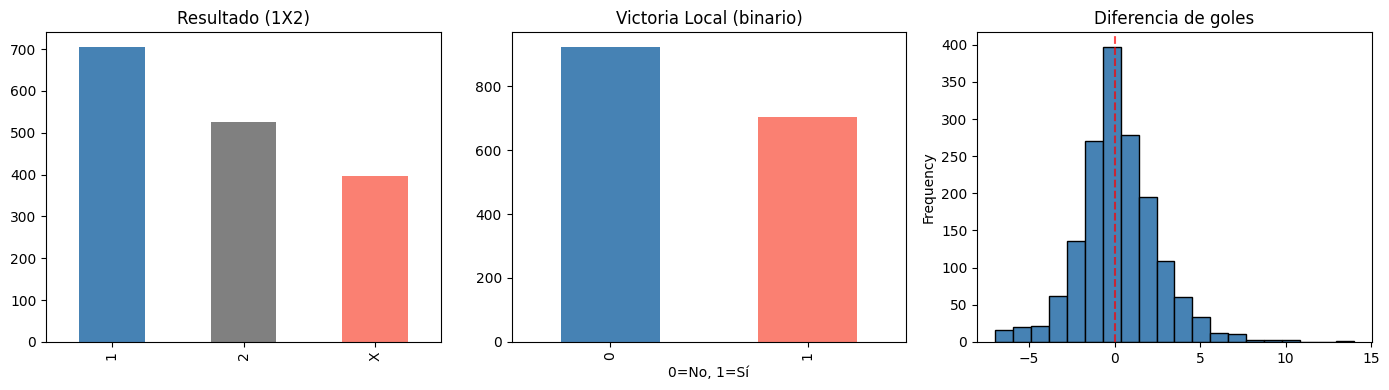

In [129]:
# Target distribution
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Match outcome (1X2)
df['Resultado_1X2'].value_counts().plot(kind='bar', ax=axes[0], title='Match Outcome (1X2)', color=['steelblue','gray','salmon'])
axes[0].set_xlabel('')

# Home win
df['Victoria_Local'].value_counts().plot(kind='bar', ax=axes[1], title='Home Win (binary)', color=['steelblue','salmon'])
axes[1].set_xlabel('0=No, 1=Yes')

# Goal difference
df['Goles_diff'].plot(kind='hist', ax=axes[2], title='Goal Difference', bins=20, color='steelblue', edgecolor='black')
axes[2].axvline(0, color='red', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


---
# Exploratory Data Analysis

The following analysis addresses the research question: **Which match performance statistics are the strongest predictors of football match outcomes?**

All figures use patterns (hatching, markers) to remain readable in black & white. Figures are numbered sequentially; tables are rounded to 3 decimal places.

### Table 2. Mean performance statistics by match outcome

Average values of key metric differences (Local − Visitante) grouped by match outcome (1 = home win, X = draw, 2 = away win). Positive values indicate a home team advantage.

In [130]:
# --- Table 2: Mean stats by outcome ---
stats_cols = ['xG_diff', 'Posesion_diff', 'Remates_puerta_diff',
              'Corneres_diff', 'Pases_Exitosos_diff', 'Paradas_diff']
stats_cols = [c for c in stats_cols if c in df.columns]

tabla = df.groupby('Resultado_1X2')[stats_cols].mean().round(3)
tabla.index.name = 'Outcome'
tabla.index = tabla.index.map({'1': '1 (Home win)', 'X': 'X (Draw)', '2': '2 (Away win)'})
tabla.columns = [c.replace('_diff', '') for c in tabla.columns]
print('Table 2. Mean performance metric differences by match outcome')
print(tabla.to_string())

# Also show match counts
print('\nMatch counts per outcome:')
print(df['Resultado_1X2'].map({'1': '1 (Home win)', 'X': 'X (Draw)', '2': '2 (Away win)'}).value_counts().sort_index().to_string())

Table 2. Mean performance metric differences by match outcome
                 xG  Posesion  Remates_puerta  Corneres  Pases_Exitosos  Paradas
Outcome                                                                         
1 (Home win)  1.300     0.146           3.950     2.668         146.771   -1.699
2 (Away win) -0.936    -0.094          -2.833    -0.859         -97.915    0.973
X (Draw)      0.144     0.021           0.481     0.542          14.542   -0.496

Match counts per outcome:
Resultado_1X2
1 (Home win)    705
2 (Away win)    526
X (Draw)        397


### Figure 2. Distribution of key performance statistics by match outcome

Box plots of performance metric differences (Local − Visitante) grouped by match outcome. A systematic shift across groups indicates predictive power. The dashed line marks zero (parity between teams).

/var/folders/c9/88zz0bpj7wx6d38dghnlklqh0000gn/T/ipykernel_29191/2986038009.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_groups, patch_artist=True, labels=tick_labels,
/var/folders/c9/88zz0bpj7wx6d38dghnlklqh0000gn/T/ipykernel_29191/2986038009.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_groups, patch_artist=True, labels=tick_labels,
/var/folders/c9/88zz0bpj7wx6d38dghnlklqh0000gn/T/ipykernel_29191/2986038009.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_groups, patch_artist=True, labels=tick_labels,
/var/folders/c9/88zz0bpj7wx6d38dgh

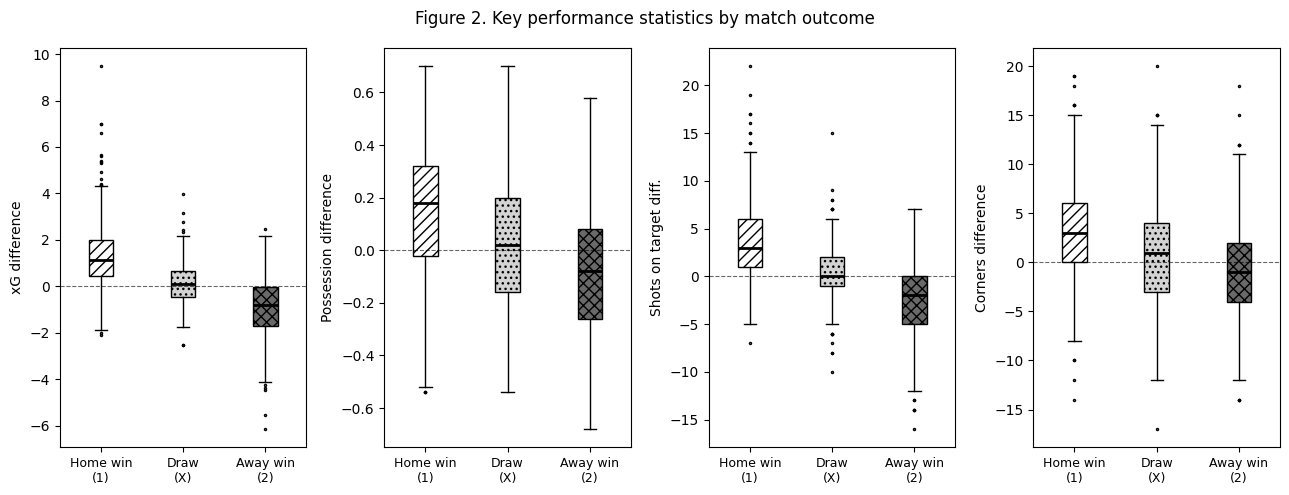

In [131]:
# --- Figure 2: Box plots by outcome ---
stats_plot = [
    ('xG_diff',           'xG difference'),
    ('Posesion_diff',      'Possession difference'),
    ('Remates_puerta_diff','Shots on target diff.'),
    ('Corneres_diff',      'Corners difference'),
]
stats_plot = [(c, l) for c, l in stats_plot if c in df.columns]

outcomes = ['1', 'X', '2']
tick_labels = ['Home win\n(1)', 'Draw\n(X)', 'Away win\n(2)']
hatches = ['///', '...', 'xxx']
facecolors = ['white', 'lightgray', 'dimgray']

fig, axes = plt.subplots(1, len(stats_plot), figsize=(13, 5))
if len(stats_plot) == 1:
    axes = [axes]

for ax, (col, ylabel) in zip(axes, stats_plot):
    data_groups = [df.loc[df['Resultado_1X2'] == o, col].dropna() for o in outcomes]
    bp = ax.boxplot(data_groups, patch_artist=True, labels=tick_labels,
                    medianprops=dict(color='black', linewidth=2),
                    flierprops=dict(marker='.', color='black', markersize=3))
    for patch, hatch, fc in zip(bp['boxes'], hatches, facecolors):
        patch.set_facecolor(fc)
        patch.set_hatch(hatch)
    ax.axhline(0, color='black', linestyle='--', linewidth=0.8, alpha=0.6)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.tick_params(axis='x', labelsize=9)

fig.suptitle('Figure 2. Key performance statistics by match outcome', fontsize=12)
plt.tight_layout()
plt.show()

### Figure 3. Correlation of match statistics with home team victory

Point-biserial correlation between each performance metric difference and the binary outcome *Victoria\_Local* (1 = home win, 0 = otherwise). Bars are ordered by absolute correlation; forward hatching (///) indicates positive association, back hatching (\\\\\\) indicates negative.

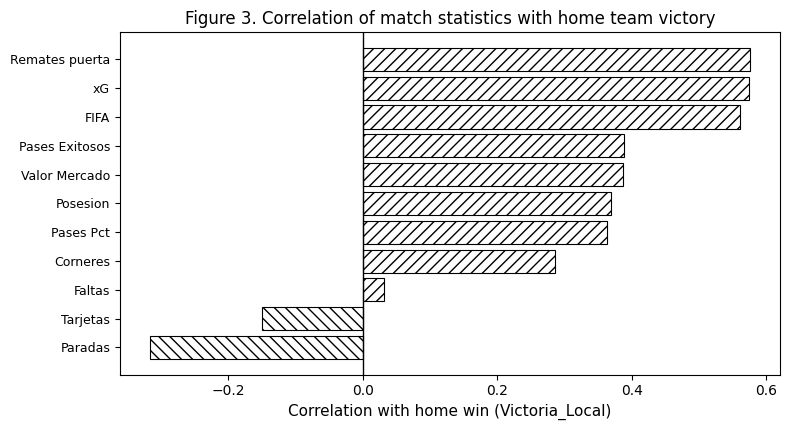

Top 5 predictors (absolute correlation):
Remates_puerta_diff    0.576
xG_diff                0.575
FIFA_diff              0.560
Pases_Exitosos_diff    0.388
Valor_Mercado_diff     0.386


In [132]:
# --- Figure 3: Correlations with Victoria_Local ---
diff_cols = [c for c in df.columns if c.endswith('_diff')
             and c not in ('Goles_diff',) and df[c].dtype != object]
corrs = (df[diff_cols + ['Victoria_Local']]
         .corr(numeric_only=True)['Victoria_Local']
         .drop('Victoria_Local')
         .dropna()
         .sort_values())

fig, ax = plt.subplots(figsize=(8, max(4, len(corrs) * 0.4)))
bars = ax.barh(range(len(corrs)), corrs.values,
               color='white', edgecolor='black', linewidth=0.8)
for bar, val in zip(bars, corrs.values):
    bar.set_hatch('///' if val >= 0 else '\\\\\\')

ax.axvline(0, color='black', linewidth=1)
ax.set_yticks(range(len(corrs)))
ax.set_yticklabels([c.replace('_diff', '').replace('_', ' ') for c in corrs.index], fontsize=9)
ax.set_xlabel('Correlation with home win (Victoria_Local)', fontsize=11)
ax.set_title('Figure 3. Correlation of match statistics with home team victory', fontsize=12)
plt.tight_layout()
plt.show()

print('Top 5 predictors (absolute correlation):')
print(corrs.abs().sort_values(ascending=False).head(5).round(3).to_string())

### Figure 4. Expected goals difference vs. goal difference

Scatter plot of xG difference against goal difference by match outcome. xG measures the quality of chances created; strong alignment with actual goals validates its use as a predictor. Outcomes are differentiated by marker shape to maintain B&W readability.

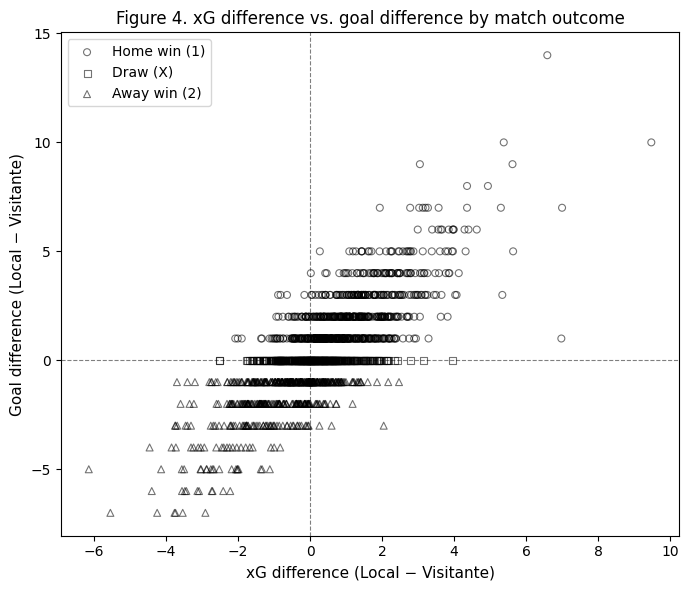

Pearson r (xG_diff vs Goles_diff): 0.781


In [133]:
# --- Figure 4: xG_diff vs Goles_diff ---
if 'xG_diff' in df.columns and 'Goles_diff' in df.columns:
    markers_map = {'1': 'o', 'X': 's', '2': '^'}
    labels_map  = {'1': 'Home win (1)', 'X': 'Draw (X)', '2': 'Away win (2)'}

    fig, ax = plt.subplots(figsize=(7, 6))
    for outcome, marker in markers_map.items():
        sub = df[df['Resultado_1X2'] == outcome].dropna(subset=['xG_diff', 'Goles_diff'])
        ax.scatter(sub['xG_diff'], sub['Goles_diff'],
                   marker=marker, s=25, alpha=0.55,
                   facecolors='none', edgecolors='black',
                   label=labels_map[outcome], linewidths=0.8)

    ax.axhline(0, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
    ax.axvline(0, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
    ax.set_xlabel('xG difference (Local − Visitante)', fontsize=11)
    ax.set_ylabel('Goal difference (Local − Visitante)', fontsize=11)
    ax.set_title('Figure 4. xG difference vs. goal difference by match outcome', fontsize=12)
    ax.legend(fontsize=10)
    plt.tight_layout()
    plt.show()

    r = df[['xG_diff', 'Goles_diff']].corr().iloc[0, 1]
    print(f'Pearson r (xG_diff vs Goles_diff): {r:.3f}')

### Figure 5. Home win rate by xG difference quartile

Home win rate across quartiles of xG difference (Q1 = largest away advantage, Q4 = largest home advantage). A monotone increase across quartiles would confirm that xG is a reliable predictor of match outcome.

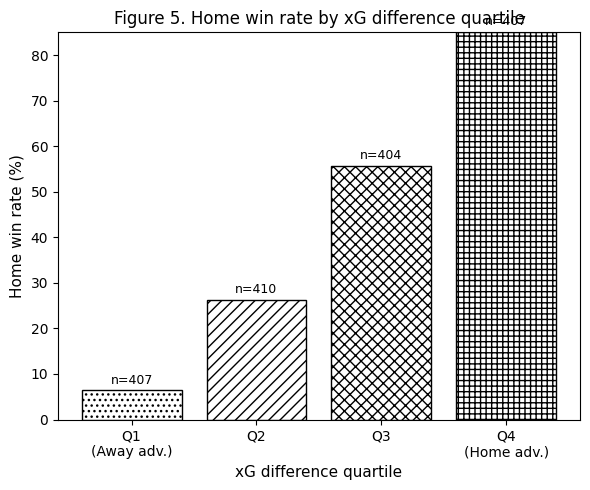

Table 3. Home win rate and match count by xG quartile
                 Win rate  Matches
xG_quartile                       
Q1\n(Away adv.)     0.064      407
Q2                  0.263      410
Q3                  0.557      404
Q4\n(Home adv.)     0.850      407


In [134]:
# --- Figure 5: Win rate by xG_diff quartile ---
if 'xG_diff' in df.columns:
    df_q = df[['xG_diff', 'Victoria_Local']].dropna().copy()
    df_q['xG_quartile'] = pd.qcut(df_q['xG_diff'], q=4,
                                   labels=['Q1\n(Away adv.)', 'Q2', 'Q3', 'Q4\n(Home adv.)'])
    wr = df_q.groupby('xG_quartile', observed=True)['Victoria_Local'].agg(['mean', 'count'])

    fig, ax = plt.subplots(figsize=(6, 5))
    hatches_q = ['...', '///', 'xxx', '+++']
    bars = ax.bar(range(len(wr)), wr['mean'] * 100,
                  color='white', edgecolor='black', linewidth=1)
    for bar, h in zip(bars, hatches_q):
        bar.set_hatch(h)
    for i, (rate, n) in enumerate(zip(wr['mean'], wr['count'])):
        ax.text(i, rate * 100 + 1.5, f'n={n}', ha='center', fontsize=9)

    ax.set_xticks(range(len(wr)))
    ax.set_xticklabels(wr.index, fontsize=10)
    ax.set_ylabel('Home win rate (%)', fontsize=11)
    ax.set_xlabel('xG difference quartile', fontsize=11)
    ax.set_title('Figure 5. Home win rate by xG difference quartile', fontsize=12)
    ax.set_ylim(0, 85)
    plt.tight_layout()
    plt.show()

    print('Table 3. Home win rate and match count by xG quartile')
    print(wr.rename(columns={'mean': 'Win rate', 'count': 'Matches'}).round(3).to_string())